In [1]:
import warnings
from utils.random import set_random_seed
from watermark import get_watermarking_pattern
from utils.vis import visualise_noise
from verify_dataset_gen import generate_verifier_training_set
warnings.filterwarnings("ignore")

# common adjustable parameters
gen_datasets = ["stablediff", "coco"]
w_patterns = ["octoweb", "ring"]

# Watermarking parameters
w_seed = 999999
w_channel = 0
w_mask_shape = 'circle'
w_radius = 10
w_measurement = 'psnr_complex'
w_injection = 'complex'
w_pattern_const  = 0
w_strength = 0.99

# Generation parameters
gen_seed = 42
num_images = 1
guidance_scale = 7.5
num_inference_steps = 50
set_random_seed(gen_seed)


In [2]:
# Image Generation Model.
import torch
from diffusers import DPMSolverMultistepScheduler
from inverse_stable_diffusion import InversableStableDiffusionPipeline

model_id = "stabilityai/stable-diffusion-2-1-base"
device = "cuda" if torch.cuda.is_available() else "cpu"
scheduler = DPMSolverMultistepScheduler.from_pretrained(model_id, subfolder="scheduler")
pipe = InversableStableDiffusionPipeline.from_pretrained(
    model_id,
    scheduler=scheduler,
    torch_dtype=torch.float16,
    revision="fp16",
)
pipe = pipe.to(device)

Couldn't connect to the Hub: 401 Client Error. (Request ID: Root=1-693b81a1-12c28bb37fef49ea4bcda20f;ba8eb83c-ba1c-4db7-83d7-364dda8c5c82)

Repository Not Found for url: https://huggingface.co/api/models/stabilityai/stable-diffusion-2-1-base/revision/fp16.
Please make sure you specified the correct `repo_id` and `repo_type`.
If you are trying to access a private or gated repo, make sure you are authenticated. For more details, see https://huggingface.co/docs/huggingface_hub/authentication
Invalid username or password..
Will try to load from local cache.


Loading pipeline components...:   0%|          | 0/5 [00:00<?, ?it/s]

`torch_dtype` is deprecated! Use `dtype` instead!
An error occurred while trying to fetch C:\Users\mike8\.cache\huggingface\hub\models--stabilityai--stable-diffusion-2-1-base\snapshots\1f758383196d38df1dfe523ddb1030f2bfab7741\unet: Error no file named diffusion_pytorch_model.safetensors found in directory C:\Users\mike8\.cache\huggingface\hub\models--stabilityai--stable-diffusion-2-1-base\snapshots\1f758383196d38df1dfe523ddb1030f2bfab7741\unet.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.
An error occurred while trying to fetch C:\Users\mike8\.cache\huggingface\hub\models--stabilityai--stable-diffusion-2-1-base\snapshots\1f758383196d38df1dfe523ddb1030f2bfab7741\vae: Error no file named diffusion_pytorch_model.safetensors found in directory C:\Users\mike8\.cache\huggingface\hub\models--stabilityai--stable-diffusion-2-1-base\snapshots\1f758383196d38df1dfe523ddb1030f2bfab7741\vae.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to 

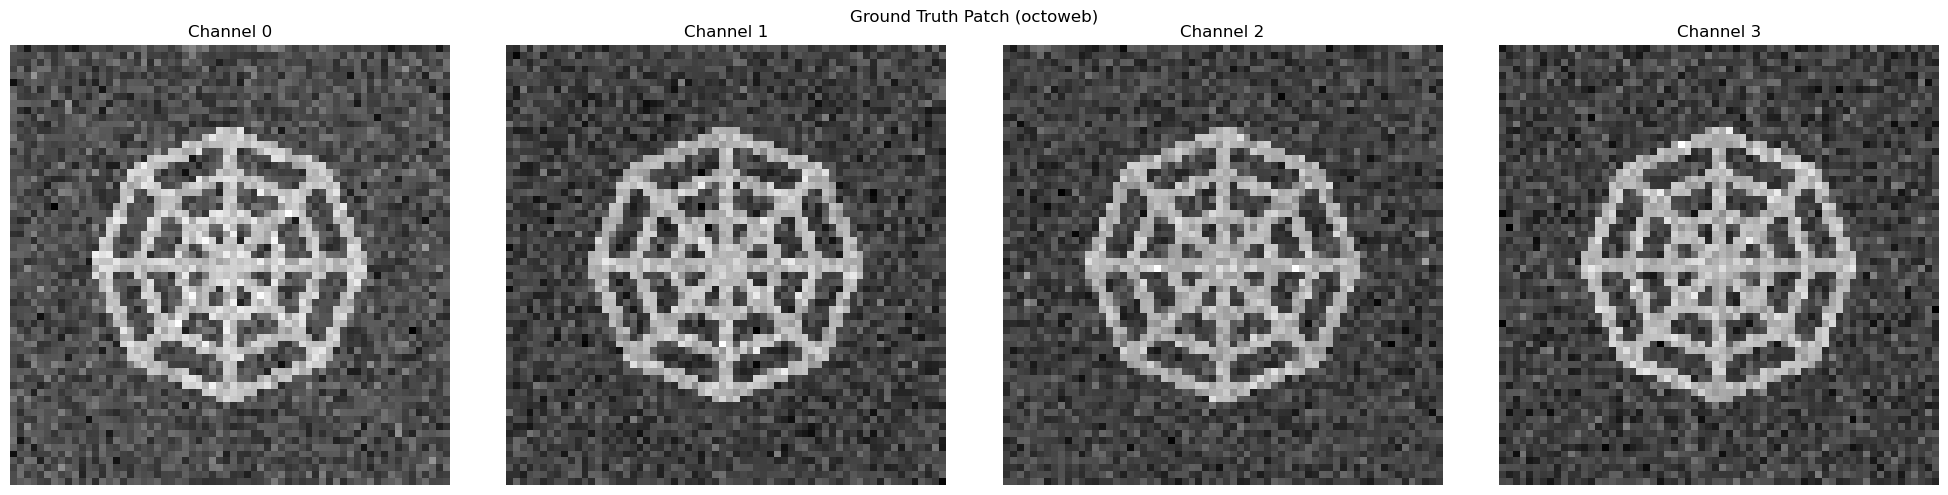

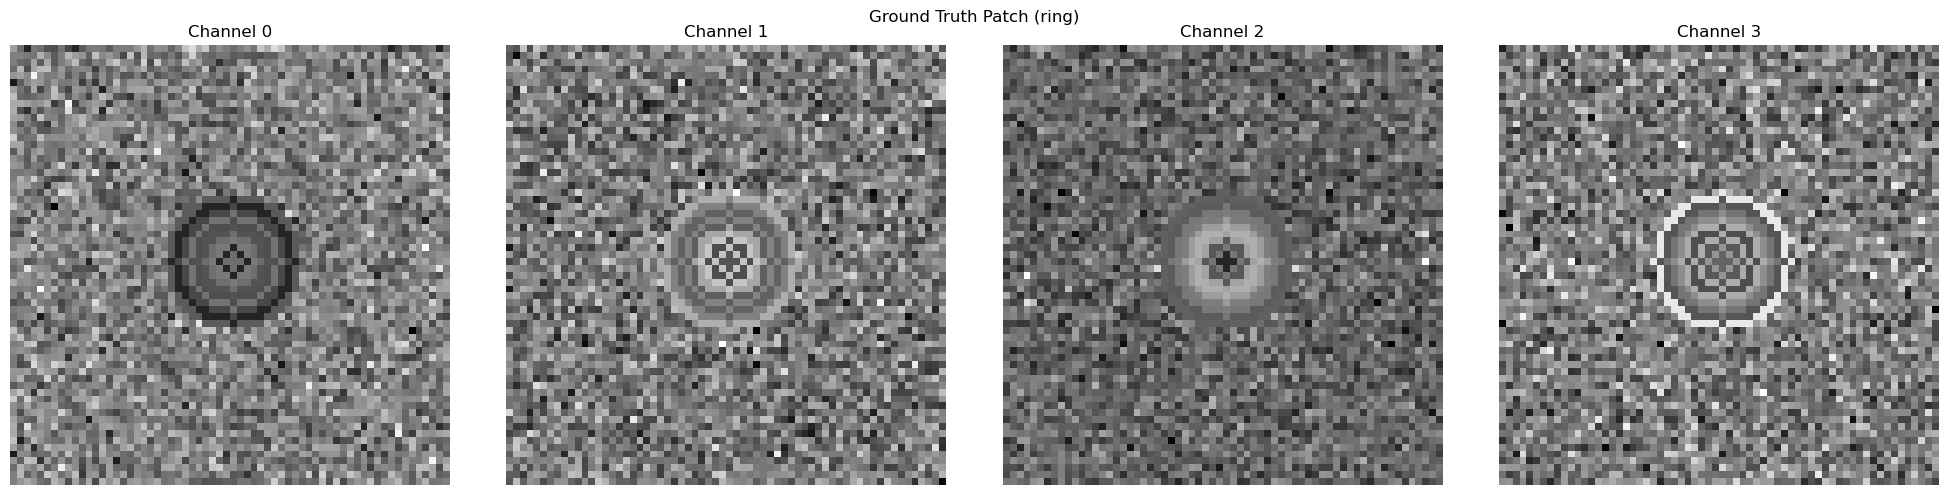

In [3]:
for w_p in w_patterns:
    visualise_noise(
        get_watermarking_pattern(
            pipe,
            w_seed=w_seed,
            w_pattern=w_p,
            w_radius=w_radius,
            device=device,
            strength=w_strength,
            shape=None,
        )[0],
        title=f"Ground Truth Patch ({w_p})",
    )

In [4]:
for gen_dataset in gen_datasets:
    for w_pattern in w_patterns:
        generate_verifier_training_set(
            gen_dataset,
            pipe,
            w_mask_shape,
            w_channel,
            w_radius,
            w_seed,
            w_pattern,
            w_strength,
            w_injection,
            gen_seed,
            num_inference_steps,
            guidance_scale,
            device,
            n_per_class=500,
        )